In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# load data
edges = pd.read_csv("edge.csv", header=None)
feat_train = pd.read_csv("node_feat_train.csv")
feat_val = pd.read_csv("node_feat_valid.csv")
feat_test = pd.read_csv("node_feat_test.csv")
year_train = pd.read_csv("node_year_train.csv")
year_val = pd.read_csv("node_year_valid.csv")
year_test = pd.read_csv("node_year_test.csv")
label_train = pd.read_csv("node_label_train.csv")
label_val = pd.read_csv("node_label_valid.csv")

In [3]:
# dataset size
print('train: {}'.format(len(feat_train)))
print('valid: {}'.format(len(feat_val)))
print('test: {}'.format(len(feat_test)))

train: 90941
valid: 29799
test: 48603


In [4]:
# unique values of label
print(sorted(label_train['0'].unique()))
print(sorted(label_val['0'].unique()))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]


/var/folders/d2/gh0v207s7wq0gn0ptj8jlx0r0000gn/T/ipykernel_47456/3591582141.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='0', data=label_train, order=range(0, 40), palette='pastel')


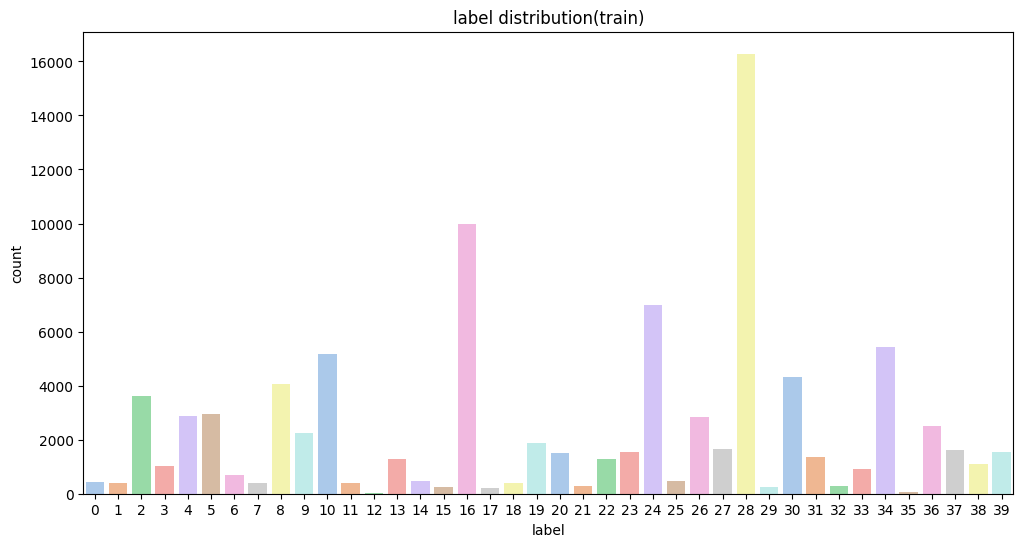

In [5]:
# label distribution(train)
plt.figure(figsize=(12, 6))
sns.countplot(x='0', data=label_train, order=range(0, 40), palette='pastel')
plt.title('label distribution(train)')
plt.xlabel('label')
plt.ylabel('count')
plt.show()

/var/folders/d2/gh0v207s7wq0gn0ptj8jlx0r0000gn/T/ipykernel_47456/1355567861.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='0', data=label_val, order=range(0, 40), palette='pastel')


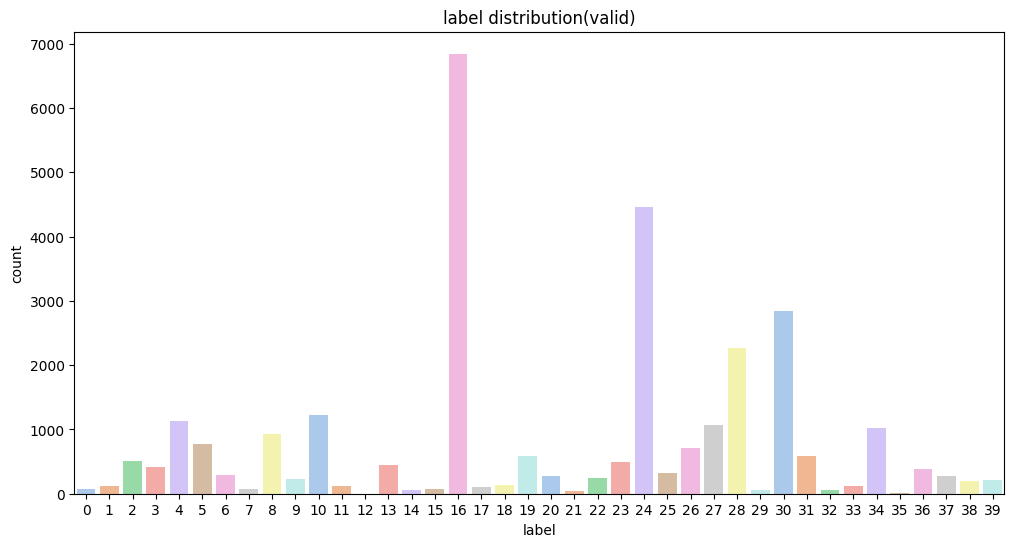

In [6]:
# label distribution(valid)
plt.figure(figsize=(12, 6))
sns.countplot(x='0', data=label_val, order=range(0, 40), palette='pastel')
plt.title('label distribution(valid)')
plt.xlabel('label')
plt.ylabel('count')
plt.show()

In [7]:
# unique values of year
print(sorted(year_train['0'].unique()))

[1971, 1986, 1987, 1988, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]


/var/folders/d2/gh0v207s7wq0gn0ptj8jlx0r0000gn/T/ipykernel_47456/1409306189.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='0', data=year_train, order=range(1971, 2018), palette='pastel')


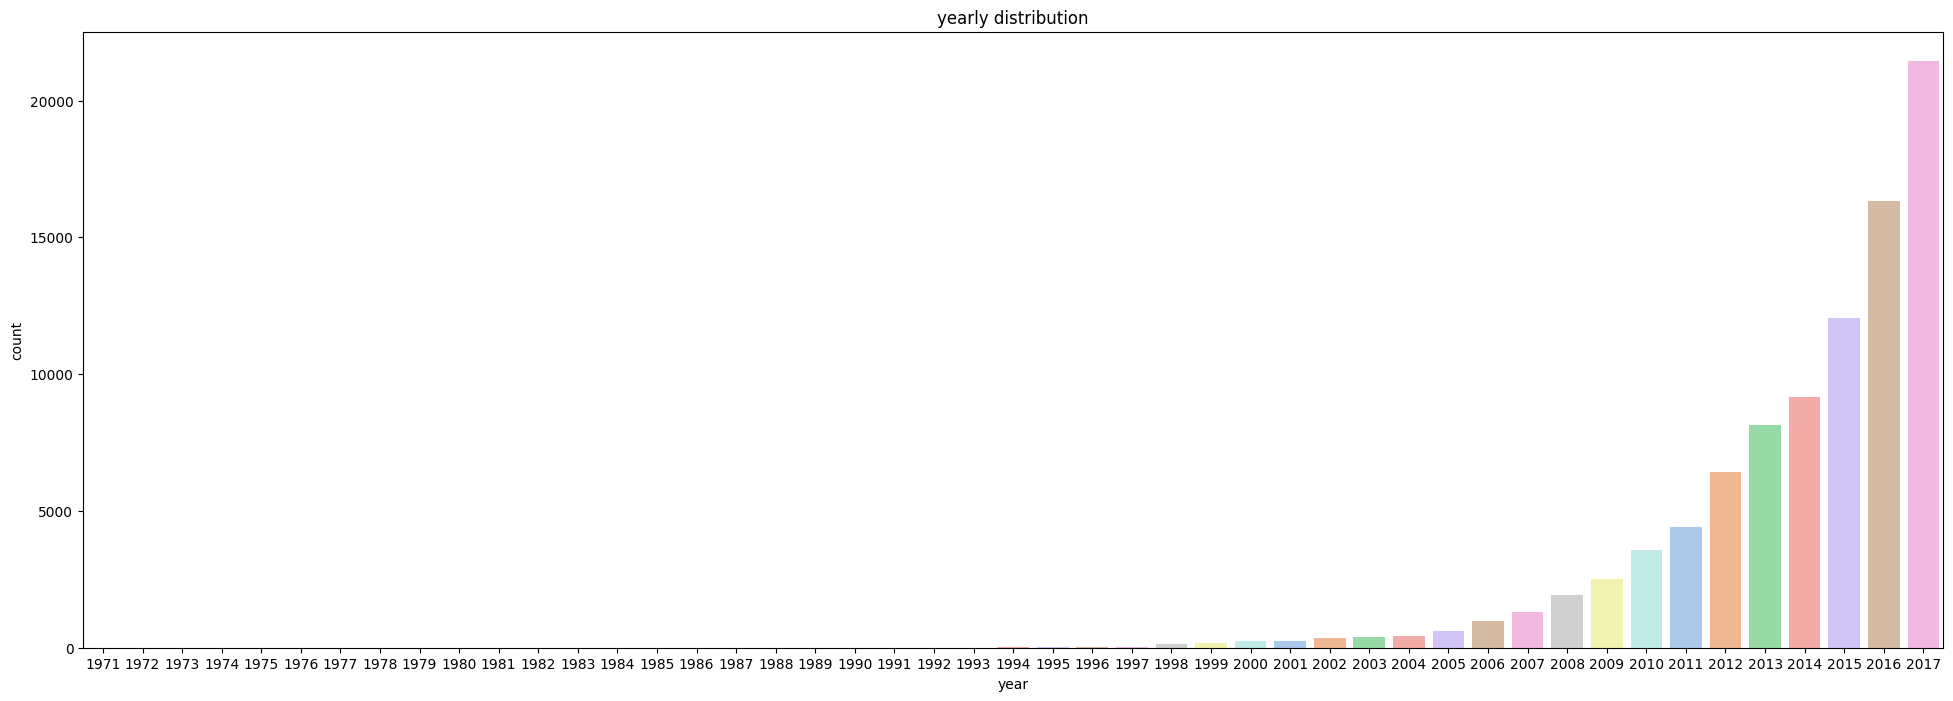

In [8]:
# yearly distribution
plt.figure(figsize=(24, 8))
sns.countplot(x='0', data=year_train, order=range(1971, 2018), palette='pastel')
plt.title('yearly distribution')
plt.xlabel('year')
plt.ylabel('count')
plt.show()

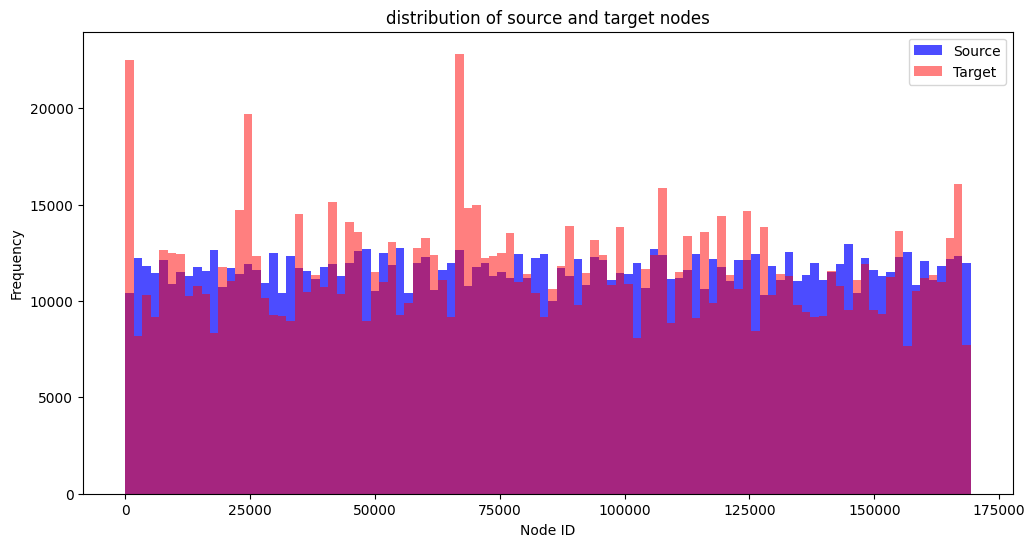

In [9]:
# degree distribution
plt.figure(figsize=(12, 6))
plt.hist(edges[0], bins=100, color='blue', alpha=0.7, label='Source')
plt.hist(edges[1], bins=100, color='red', alpha=0.5, label='Target')
plt.title('distribution of source and target nodes')
plt.xlabel('Node ID')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [10]:
years = pd.concat([year_train, year_val, year_test], axis=0).sort_values('id')
years

,id,0
0,0,2013
1,1,2015
2,2,2014
3,3,2014
4,4,2014
...,...,...
48598,169338,2020
48599,169339,2020
48600,169340,2020
48601,169341,2020


In [11]:
# data validation
years = pd.concat([year_train, year_val, year_test], axis=0).sort_values('id').values
id_year_map = {id: year for id, year in years}
edge_index = edges.values
mask = np.array([id_year_map[i] < id_year_map[j] for i, j in edge_index])
print(len(edge_index[mask]))

20903


In [12]:
edges

,0,1
0,104447,13091
1,15858,47283
2,107156,69161
3,107156,136440
4,107156,107366
...,...,...
1166238,45118,79124
1166239,45118,147994
1166240,45118,162473
1166241,45118,162537
